In [2]:
%pip install xgboost optuna mlflow imbalanced-learn -q

In [1]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive
!git clone https://github.com/proust-19/credit-risk-prediction.git
%cd credit-risk-prediction

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive
Cloning into 'credit-risk-prediction'...
remote: Enumerating objects: 94, done.
remote: Counting objects: 100% (94/94), done.
remote: Compressing objects: 100% (57/57), done.
remote: Total 94 (delta 28), reused 83 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (94/94), 1.00 MiB | 5.88 MiB/s, done.
Resolving deltas: 100% (28/28), done.
/content/drive/MyDrive/credit-risk-prediction


In [1]:
import sys
import numpy	as np
import pandas as pd
import joblib
import mlflow
import mlflow.sklearn
import optuna

from xgboost	import XGBClassifier
from sklearn.metrics	import classification_report, confusion_matrix, roc_auc_score, f1_score
from sklearn.model_selection import cross_val_score, StratifiedKFold

sys.path.append('..')
X_train_raw, X_test, y_train_raw, y_test = joblib.load('../data/processed/train_test_split.pkl')

print(f"Train: {X_train_raw.shape}, Test: {X_test.shape}")
print(f"Class distribution: {y_train_raw.value_counts().to_dict()}")
print(f"Class distribution: {y_test.value_counts().to_dict()}")

Train: (1118, 33), Test: (200, 33)
Class distribution: {1: 559, 0: 559}
Class distribution: {0: 141, 1: 59}


In [2]:
neg = (y_train_raw == 0).sum()
pos = (y_train_raw == 1).sum()
spw = neg / pos

# Retrain baseline with scale_pos_weight instead of SMOTE
xgb_weighted = XGBClassifier(
   n_estimators=100,
   scale_pos_weight=spw,
   eval_metric='logloss',
   random_state=42,
   use_label_encoder=False
)
xgb_weighted.fit(X_train_raw, y_train_raw)

y_pred = xgb_weighted.predict(X_test)
y_pred_proba = xgb_weighted.predict_proba(X_test)[:, 1]

print(f"F1: {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

F1: 0.6727
ROC-AUC: 0.8275
              precision    recall  f1-score   support

           0       0.85      0.90      0.88       141
           1       0.73      0.63      0.67        59

    accuracy                           0.82       200
   macro avg       0.79      0.76      0.77       200
weighted avg       0.81      0.82      0.82       200

[[127  14]
 [ 22  37]]


/home/purshotam_kumar/ml_projects/project-1/venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [16:56:15] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [3]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

y_pred_proba	= xgb_weighted.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-9)
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]

print(f"Best threshold: {best_threshold:.4f}, F1: {f1_scores[best_idx]:.4f}")

print("\n=== Threshold Sensitivity ===")
for t in [0.30, 0.35, 0.40, 0.45, 0.50]:
  y_t = (y_pred_proba >= t).astype(int)
  tn, fp, fn, tp = confusion_matrix(y_test, y_t).ravel()
  f1 = f1_score(y_test, y_t)
  print(f"t={t:.2f} | F1={f1:.4f} | Recall(bad)={tp/(tp+fn):.2f} | FN={fn} | FP={fp}")

Best threshold: 0.3533, F1: 0.6984

=== Threshold Sensitivity ===
t=0.30 | F1=0.6767 | Recall(bad)=0.76 | FN=14 | FP=29
t=0.35 | F1=0.6984 | Recall(bad)=0.75 | FN=15 | FP=23
t=0.40 | F1=0.6721 | Recall(bad)=0.69 | FN=18 | FP=22
t=0.45 | F1=0.6435 | Recall(bad)=0.63 | FN=22 | FP=19
t=0.50 | F1=0.6727 | Recall(bad)=0.63 | FN=22 | FP=14


In [4]:
threshold = 0.35
with mlflow.start_run(run_name="XGBoost_Threshold_Tuned"):
    y_pred_final = (y_pred_proba >= threshold).astype(int)
    
    f1 = f1_score(y_test, y_pred_final)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final).ravel()
    
    mlflow.log_param("threshold", threshold)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("roc_auc", roc_auc)
    mlflow.log_metric("false_negatives", fn)
    mlflow.log_metric("false_positives", fp)
    mlflow.log_metric("recall_bad_credit", tp / (tp + fn))
    
    print("=== Final Model Threshold ===")
    print(f"Threshold:      {threshold}")
    print(f"F1 Score:       {f1:.4f}")
    print(f"ROC-AUC:        {roc_auc:.4f}")
    print(f"Recall (bad):   {tp/(tp+fn):.2f}  → catching {tp} of {tp+fn} defaulters")
    print(f"False Negatives: {fn}  → bad loans approved")
    print(f"False Positives: {fp}  → good loans rejected")
    print(classification_report(y_test, y_pred_final))
    print(confusion_matrix(y_test, y_pred_final))

=== Final Model Threshold ===
Threshold:      0.35
F1 Score:       0.6984
ROC-AUC:        0.8275
Recall (bad):   0.75  → catching 44 of 59 defaulters
False Negatives: 15  → bad loans approved
False Positives: 23  → good loans rejected
              precision    recall  f1-score   support

           0       0.89      0.84      0.86       141
           1       0.66      0.75      0.70        59

    accuracy                           0.81       200
   macro avg       0.77      0.79      0.78       200
weighted avg       0.82      0.81      0.81       200

[[118  23]
 [ 15  44]]


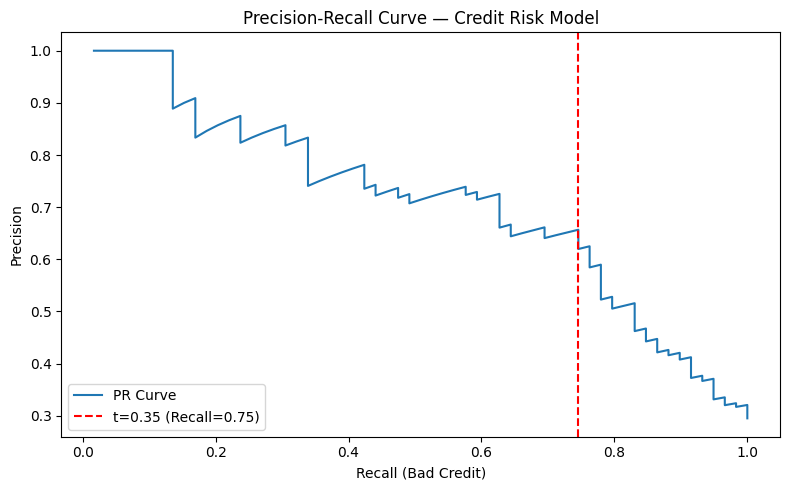

In [5]:
plt.figure(figsize=(8, 5))
plt.plot(recall[:-1], precision[:-1], label="PR Curve")
plt.axvline(x=tp/(tp+fn), color='red', linestyle='--', label=f"t=0.35 (Recall={tp/(tp+fn):.2f})")
plt.xlabel("Recall (Bad Credit)")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Credit Risk Model")
plt.legend()
plt.tight_layout()
plt.savefig('../models/pr_curve.png')
plt.show()

In [6]:
import json

joblib.dump(xgb_weighted, '../models/xgb_final.pkl')

model_config = {
    "model_path": "models/xgb_final.pkl",
    "threshold": threshold,
    "n_estimators": 100,
    "f1_score": round(f1, 4),
    "roc_auc": round(roc_auc, 4),
    "false_negatives": int(fn),
    "false_positives": int(fp),
    "recall_bad_credit": round(tp/(tp+fn), 4)
}

with open('../models/model_config.json', 'w') as f:
    json.dump(model_config, f, indent=2)

print("Model and config saved.")
print(json.dumps(model_config, indent=2))

Model and config saved.
{
  "model_path": "models/xgb_final.pkl",
  "threshold": 0.35,
  "n_estimators": 100,
  "f1_score": 0.6984,
  "roc_auc": 0.8275,
  "false_negatives": 15,
  "false_positives": 23,
  "recall_bad_credit": 0.7458
}


### Keeping the cell for refrence to show the attempt that i did is not so effective. So, i am dropping the idea of fine tuning of this model. ###

In [ ]:
# this is the tuning cell, done before threshold analysis but we got worse results than the baseline, so we kept the baseline and just tuned the threshold
# it is left here for reference and future tuning attempts, but it is not used in the final model

mlflow.set_experiment("credit-risk-tuning")

def objective(trial):
  params = {
    "n_estimators": trial.suggest_int("n_estimators", 100, 500),
    "max_depth": trial.suggest_int("max_depth", 3, 9),
    "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
    "subsample": trial.suggest_float("subsample", 0.6, 1.0),
    "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
    "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
    "gamma": trial.suggest_float("gamma", 0.0, 5.0),
    "eval_metric": "logloss",
    "random_state": 42,
    "use_label_encoder": False,
		}
  
  model = XGBClassifier(**params)

  cv = StratifiedKFold(n_splits=5, shuffle= True, random_state=42)
  scores = cross_val_score(model, X_train_raw, y_train_raw, cv=cv, scoring="f1", n_jobs=-1)
  
  return scores.mean()

In [8]:
study = optuna.create_study(direction="maximize", study_name="xgb_f1_optimization")
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest F1 (CV): {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

[I 2026-03-19 13:51:08,866] A new study created in memory with name: xgb_f1_optimization


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-03-19 13:51:12,043] Trial 0 finished with value: 0.7853001484461624 and parameters: {'n_estimators': 198, 'max_depth': 4, 'learning_rate': 0.05707528213659155, 'subsample': 0.6972024610014991, 'colsample_bytree': 0.8139231247313812, 'min_child_weight': 10, 'gamma': 4.921226181951747}. Best is trial 0 with value: 0.7853001484461624.
[I 2026-03-19 13:51:12,682] Trial 1 finished with value: 0.806060648944128 and parameters: {'n_estimators': 432, 'max_depth': 5, 'learning_rate': 0.0816790520628891, 'subsample': 0.7931075240063087, 'colsample_bytree': 0.7198437827466246, 'min_child_weight': 4, 'gamma': 4.563709948022341}. Best is trial 1 with value: 0.806060648944128.
[I 2026-03-19 13:51:13,134] Trial 2 finished with value: 0.7950470991633829 and parameters: {'n_estimators': 171, 'max_depth': 9, 'learning_rate': 0.023205639100548278, 'subsample': 0.7322542716274295, 'colsample_bytree': 0.606755245482098, 'min_child_weight': 8, 'gamma': 3.1050613544824737}. Best is trial 1 with value

In [ ]:
best_params = study.best_params
best_params["eval_metric"] = "logloss"
best_params["random_state"] = 42
best_params["use_label_encoder"] = False

with mlflow.start_run(run_name="XGBoost_Tuned_optuna"):
  model = XGBClassifier(**best_params)
  model.fit(X_train_raw, y_train_raw)
  
  y_pred = model.predict(X_test)
  y_pred_proba = model.predict_proba(X_test)[:, 1]
  
  f1 = f1_score(y_test, y_pred)
  roc_auc = roc_auc_score(y_test, y_pred_proba)
  
  mlflow.log_params(best_params)
  mlflow.log_metric("f1_score", f1)
  mlflow.log_metric("roc_auc", roc_auc)
  mlflow.sklearn.log_model(model, "model")
  
  print("=== Tuned XGBoost Results ===")
  print(f"F1 Score:  {f1:.4f}")
  print(f"ROC-AUC:   {roc_auc:.4f}")
  print("\nClassification Report:")
  print(classification_report(y_test, y_pred))
  print("Confusion Matrix:")
  print(confusion_matrix(y_test, y_pred))
  

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:59:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
2026/03/19 13:59:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/19 13:59:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


=== Tuned XGBoost Results ===
F1 Score:  0.5825
ROC-AUC:   0.8392

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.90      0.86       141
           1       0.68      0.51      0.58        59

    accuracy                           0.79       200
   macro avg       0.75      0.70      0.72       200
weighted avg       0.78      0.79      0.77       200

Confusion Matrix:
[[127  14]
 [ 29  30]]
